## Visualização

Nesse notebook são produzidas as visualizações dos dados

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import Rectangle, Polygon
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
from utils.load_shp import load_shp
from utils.load_csv import load_csv
from utils.save_graph import save_graph

In [2]:
mapa = load_shp("mapa.shp")

dados = load_csv("dados.csv")

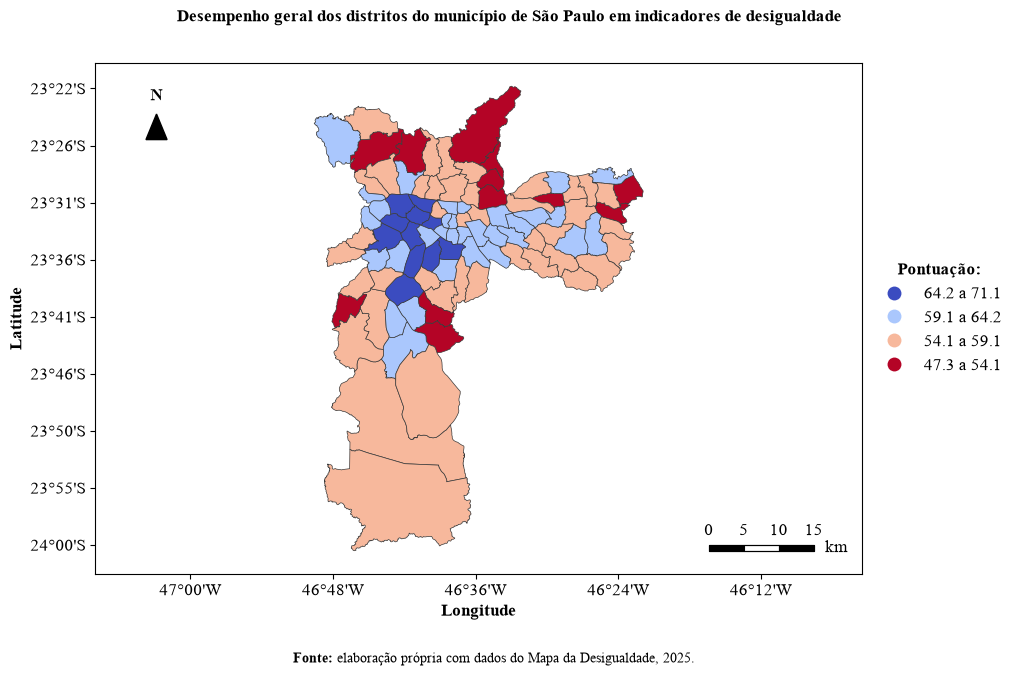

In [3]:
mapa_wgs84 = mapa.to_crs(epsg=4326)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif"
]

def format_lon(x, pos):
    graus = int(abs(x))
    minutos = int(round((abs(x) - graus) * 60))
    return f"{graus}°{minutos:02d}'W"

def format_lat(y, pos):
    graus = int(abs(y))
    minutos = int(round((abs(y) - graus) * 60))
    return f"{graus}°{minutos:02d}'S"

def add_north_arrow(ax, x, y, size=0.05):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    largura_x = xlim[1] - xlim[0]
    altura_y = ylim[1] - ylim[0]

    x_data = xlim[0] + x * largura_x
    y_data = ylim[0] + y * altura_y

    seta_altura = altura_y * size
    seta_largura = largura_x * size * 0.55

    triangulo = Polygon(
        [
            (x_data, y_data + seta_altura),
            (x_data - seta_largura / 2, y_data),
            (x_data + seta_largura / 2, y_data),
        ],
        closed=True,
        facecolor="black",
        edgecolor="black",
        zorder=5
    )
    ax.add_patch(triangulo)

    ax.text(
        x_data,
        y_data + seta_altura + altura_y * 0.02,
        "N",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        zorder=5
    )

def add_scale_bar(ax, length_km, location=(0.62, 0.04), height_frac=0.012):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    lat_ref = (ylim[0] + ylim[1]) / 2
    km_por_grau = 111.32 * np.cos(np.radians(lat_ref))
    comprimento_graus = length_km / km_por_grau

    largura_x = xlim[1] - xlim[0]
    altura_y = ylim[1] - ylim[0]

    x0 = xlim[0] + location[0] * largura_x
    y0 = ylim[0] + location[1] * altura_y
    h = altura_y * height_frac

    n_blocos = 3
    bloco = comprimento_graus / n_blocos

    for i in range(n_blocos):
        cor = "black" if i % 2 == 0 else "white"
        rect = Rectangle(
            (x0 + i * bloco, y0),
            bloco,
            h,
            facecolor=cor,
            edgecolor="black",
            linewidth=0.8,
            zorder=5
        )
        ax.add_patch(rect)

    ax.add_patch(
        Rectangle(
            (x0, y0), comprimento_graus, h,
            fill=False, edgecolor="black", linewidth=0.8, zorder=6
        )
    )

    for i in range(n_blocos + 1):
        valor = int(round(i * length_km / n_blocos))
        ax.text(
            x0 + i * bloco,
            y0 + h + altura_y * 0.012,
            f"{valor}",
            ha="center",
            va="bottom",
            fontsize=12,
            zorder=6
        )

    ax.text(
        x0 + comprimento_graus + largura_x * 0.015,
        y0 + h / 2,
        "km",
        ha="left",
        va="center",
        fontsize=12,
        zorder=6
    )

fig, ax = plt.subplots(figsize=(13, 7))
plt.subplots_adjust(left=0.06, right=0.65, bottom=0.15, top=0.88)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

mapa_wgs84.plot(
    column="pontuacao",
    cmap="coolwarm_r",
    linewidth=0.5,
    edgecolor="#3a3a3a",
    ax=ax,
    legend=True,
    scheme="NaturalBreaks",
    k=4,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1.05, 0.5),
        "fmt": "{:.1f}",
        "title": "Pontuação:",
        "frameon": False,
        "fontsize": 12,
        "title_fontsize": 12,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "Sem dado"
    }
)

leg = ax.get_legend()

handles = leg.legend_handles
labels = [txt.get_text() for txt in leg.get_texts()]
labels = [label.replace(", ", " a ") for label in labels]

leg.remove()

ax.legend(
    handles[::-1],
    labels[::-1],
    title="Pontuação:",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=12,
    title_fontproperties={"size": 12, "weight": "bold"}
)

ax.set_aspect("equal", adjustable="datalim")
fig.canvas.draw()

add_north_arrow(ax, x=0.08, y=0.85, size=0.05)

add_scale_bar(ax, length_km=15, location=(0.8, 0.045))

ax.yaxis.set_major_locator(MaxNLocator(nbins=9))
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

ax.set_title(
    "Desempenho geral dos distritos do município de São Paulo em indicadores de desigualdade",
    fontsize=12,
    fontweight="bold",
    pad=30,
    x = 0.54
)

texto_negrito = TextArea(
    "Fonte: ",
    textprops=dict(fontsize=10, fontweight="bold", color="black")
)
texto_normal = TextArea(
    "elaboração própria com dados do Mapa da Desigualdade, 2025.",
    textprops=dict(fontsize=10, fontweight="normal", color="black")
)

caixa_fonte = HPacker(
    children=[texto_negrito, texto_normal],
    align="center",
    pad=0,
    sep=0
)

ab = AnnotationBbox(
    caixa_fonte,
    (0.38, 0.03),
    xycoords="figure fraction",
    box_alignment=(0.5, 0.5),
    frameon=False
)
fig.add_artist(ab)

save_graph(fig, "mapa_desigualdade")

plt.show()

C:\Users\caiod\AppData\Local\Temp\ipykernel_7744\1180641570.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.04,1,0.95])


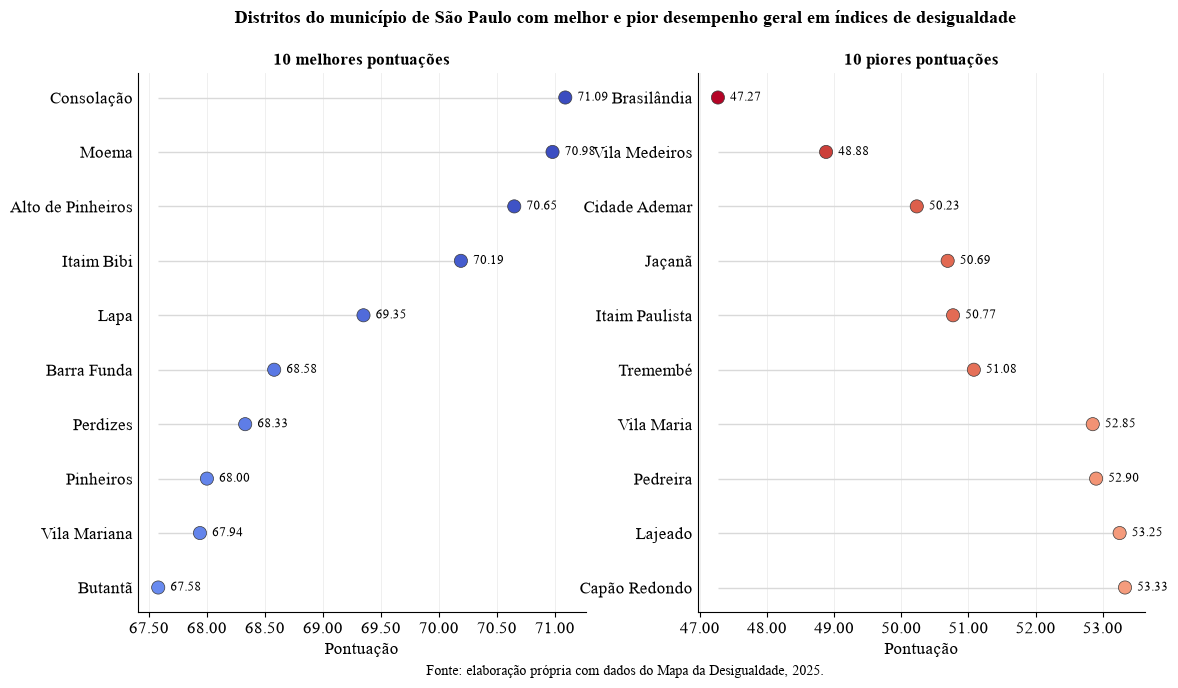

In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif"
]

ranking = (
    dados[["distrito", "pontuacao"]]
    .sort_values("pontuacao", ascending=False)
    .reset_index(drop=True)
)

top10 = ranking.head(10).copy()

bottom10 = (
    ranking.tail(10)
    .sort_values("pontuacao", ascending=True)
    .reset_index(drop=True)
)

norm = mpl.colors.Normalize(
    vmin=ranking["pontuacao"].min(),
    vmax=ranking["pontuacao"].max()
)

cores_top = cm.coolwarm_r(norm(top10["pontuacao"]))
cores_bottom = cm.coolwarm_r(norm(bottom10["pontuacao"]))

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(13, 7),
    gridspec_kw={"wspace":0.25}
)

fig.patch.set_facecolor("white")

def painel(ax, dados, cores, titulo):

    ax.set_facecolor("white")

    xmin = dados["pontuacao"].min()

    ax.hlines(
        y=range(len(dados)),
        xmin=xmin,
        xmax=dados["pontuacao"],
        color="#d9d9d9",
        linewidth=1
    )

    ax.scatter(
        dados["pontuacao"],
        range(len(dados)),
        s=90,
        color=cores,
        edgecolor="#3a3a3a",
        linewidth=0.5,
        zorder=3
    )

    offset = (
        dados["pontuacao"].max() -
        dados["pontuacao"].min()
    ) * 0.03

    for y, valor in enumerate(dados["pontuacao"]):

        ax.text(
            valor + offset,
            y,
            f"{valor:.2f}",
            va="center",
            fontsize=9
        )

    ax.set_yticks(range(len(dados)))
    ax.set_yticklabels(
        dados["distrito"],
        fontsize=12
    )

    ax.invert_yaxis()

    ax.grid(
        axis="x",
        color="#ececec",
        linewidth=0.6
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="y",
        length=0
    )

    ax.tick_params(
        axis="x",
        labelsize=12
    )

    ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.2f")
    )

    ax.set_xlabel(
        "Pontuação",
        fontsize=12
    )

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight="bold"
    )

painel(
    ax1,
    top10,
    cores_top,
    "10 melhores pontuações"
)

painel(
    ax2,
    bottom10,
    cores_bottom,
    "10 piores pontuações"
)

fig.suptitle(
    "Distritos do município de São Paulo com melhor e pior desempenho geral em índices de desigualdade",
    fontsize=13,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.02,
    "Fonte: elaboração própria com dados do Mapa da Desigualdade, 2025.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0,0.04,1,0.95])

plt.show()